# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [2]:
can_df = pd.read_csv("cancer.csv")  
can_df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [3]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done
#can_df = can_df.drop("ID", axis=1)
#ID column - i will drop it after duplicate removal

In [4]:
can_df.head()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [5]:
can_df.dtypes

ID                              int64
ClumpThickness                  int64
Cell Size                       int64
Cell Shape                      int64
Marginal Adhesion               int64
Single Epithelial Cell Size     int64
Bare Nuclei                    object
Normal Nucleoli                 int64
Bland Chromatin                 int64
Mitoses                         int64
Class                           int64
dtype: object

In [6]:
can_df.shape

(699, 11)

In [7]:
#expectation was all columns should be numeric. But data type of 'Bare Nuclei' column is Object. Lets check the unique values in 
# 'Bare Nuclei' column.
#can_df['Bare Nuclei'].unique()

# This column has '?'. 
# Lets drop the rows which have '?' in 'Bare Nuclei' column

#can_df = can_df[can_df['Bare Nuclei'] != '?']


In [8]:
#can_df['Bare Nuclei'].unique()

In [9]:
#can_df.shape

# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [10]:
col = can_df.columns
print(col)

Index(['ID', 'ClumpThickness', 'Cell Size', 'Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Normal Nucleoli',
       'Bland Chromatin', 'Mitoses', 'Class'],
      dtype='object')


In [11]:
# Printing unique values of all columns except ID column
for i in col:
    if (i != 'ID'):
        print('column name:',i)
        print('unique values:',can_df[i].unique())

column name: ClumpThickness
unique values: [ 5  3  6  4  8  1  2  7 10  9]
column name: Cell Size
unique values: [ 1  4  8 10  2  3  7  5  6  9]
column name: Cell Shape
unique values: [ 1  4  8 10  2  3  5  6  7  9]
column name: Marginal Adhesion
unique values: [ 1  5  3  8 10  4  6  2  9  7]
column name: Single Epithelial Cell Size
unique values: [ 2  7  3  1  6  4  5  8 10  9]
column name: Bare Nuclei
unique values: ['1' '10' '2' '4' '3' '9' '7' '?' '5' '8' '6']
column name: Normal Nucleoli
unique values: [ 3  9  1  2  4  5  7  8  6 10]
column name: Bland Chromatin
unique values: [ 1  2  7  4  5  3 10  6  9  8]
column name: Mitoses
unique values: [ 1  5  4  2  3  7 10  8  6]
column name: Class
unique values: [2 4]


In [12]:
# We could see "?" values in column, this should be removed from data set
# Check for missing value in any other column
can_df.isna().sum()

ID                             0
ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [13]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?
can_df[can_df['Bare Nuclei'] == '?'].count()

ID                             16
ClumpThickness                 16
Cell Size                      16
Cell Shape                     16
Marginal Adhesion              16
Single Epithelial Cell Size    16
Bare Nuclei                    16
Normal Nucleoli                16
Bland Chromatin                16
Mitoses                        16
Class                          16
dtype: int64

In [14]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
val = can_df[can_df['Bare Nuclei'] != '?']['Bare Nuclei']

In [15]:
val.unique()

array(['1', '10', '2', '4', '3', '9', '7', '5', '8', '6'], dtype=object)

In [16]:
# Here we would like to impute it with median value
can_df["Bare Nuclei"].replace('?',val.median(),inplace=True)


In [17]:
#Checking if ? is replaced by median or not
can_df[can_df['Bare Nuclei'] == '?']

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class


In [18]:
can_df['Bare Nuclei'].unique()

array(['1', '10', '2', '4', '3', '9', '7', 1.0, '5', '8', '6'],
      dtype=object)

# Q4. Perform bi variate analysis including correlation & pairplots. 


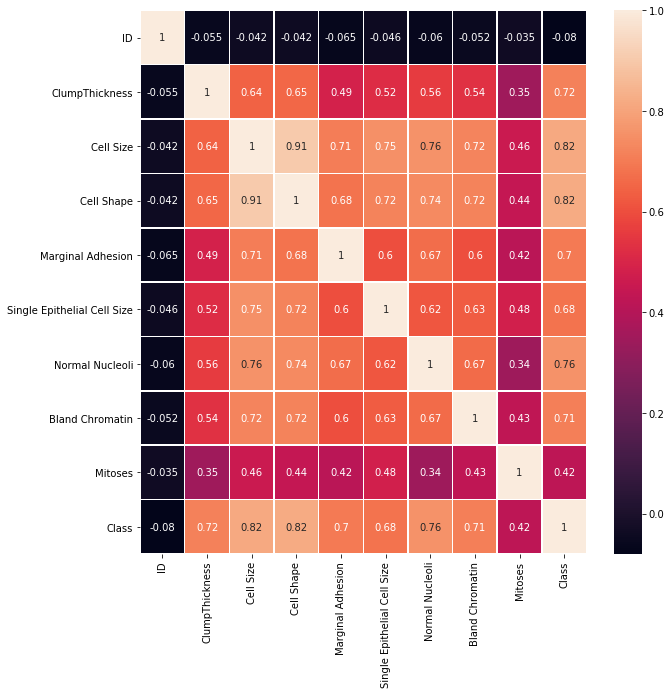

In [19]:
# Check for correlation of variable
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(can_df.corr(),annot=True,linewidths=.5, ax=ax)

In [20]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


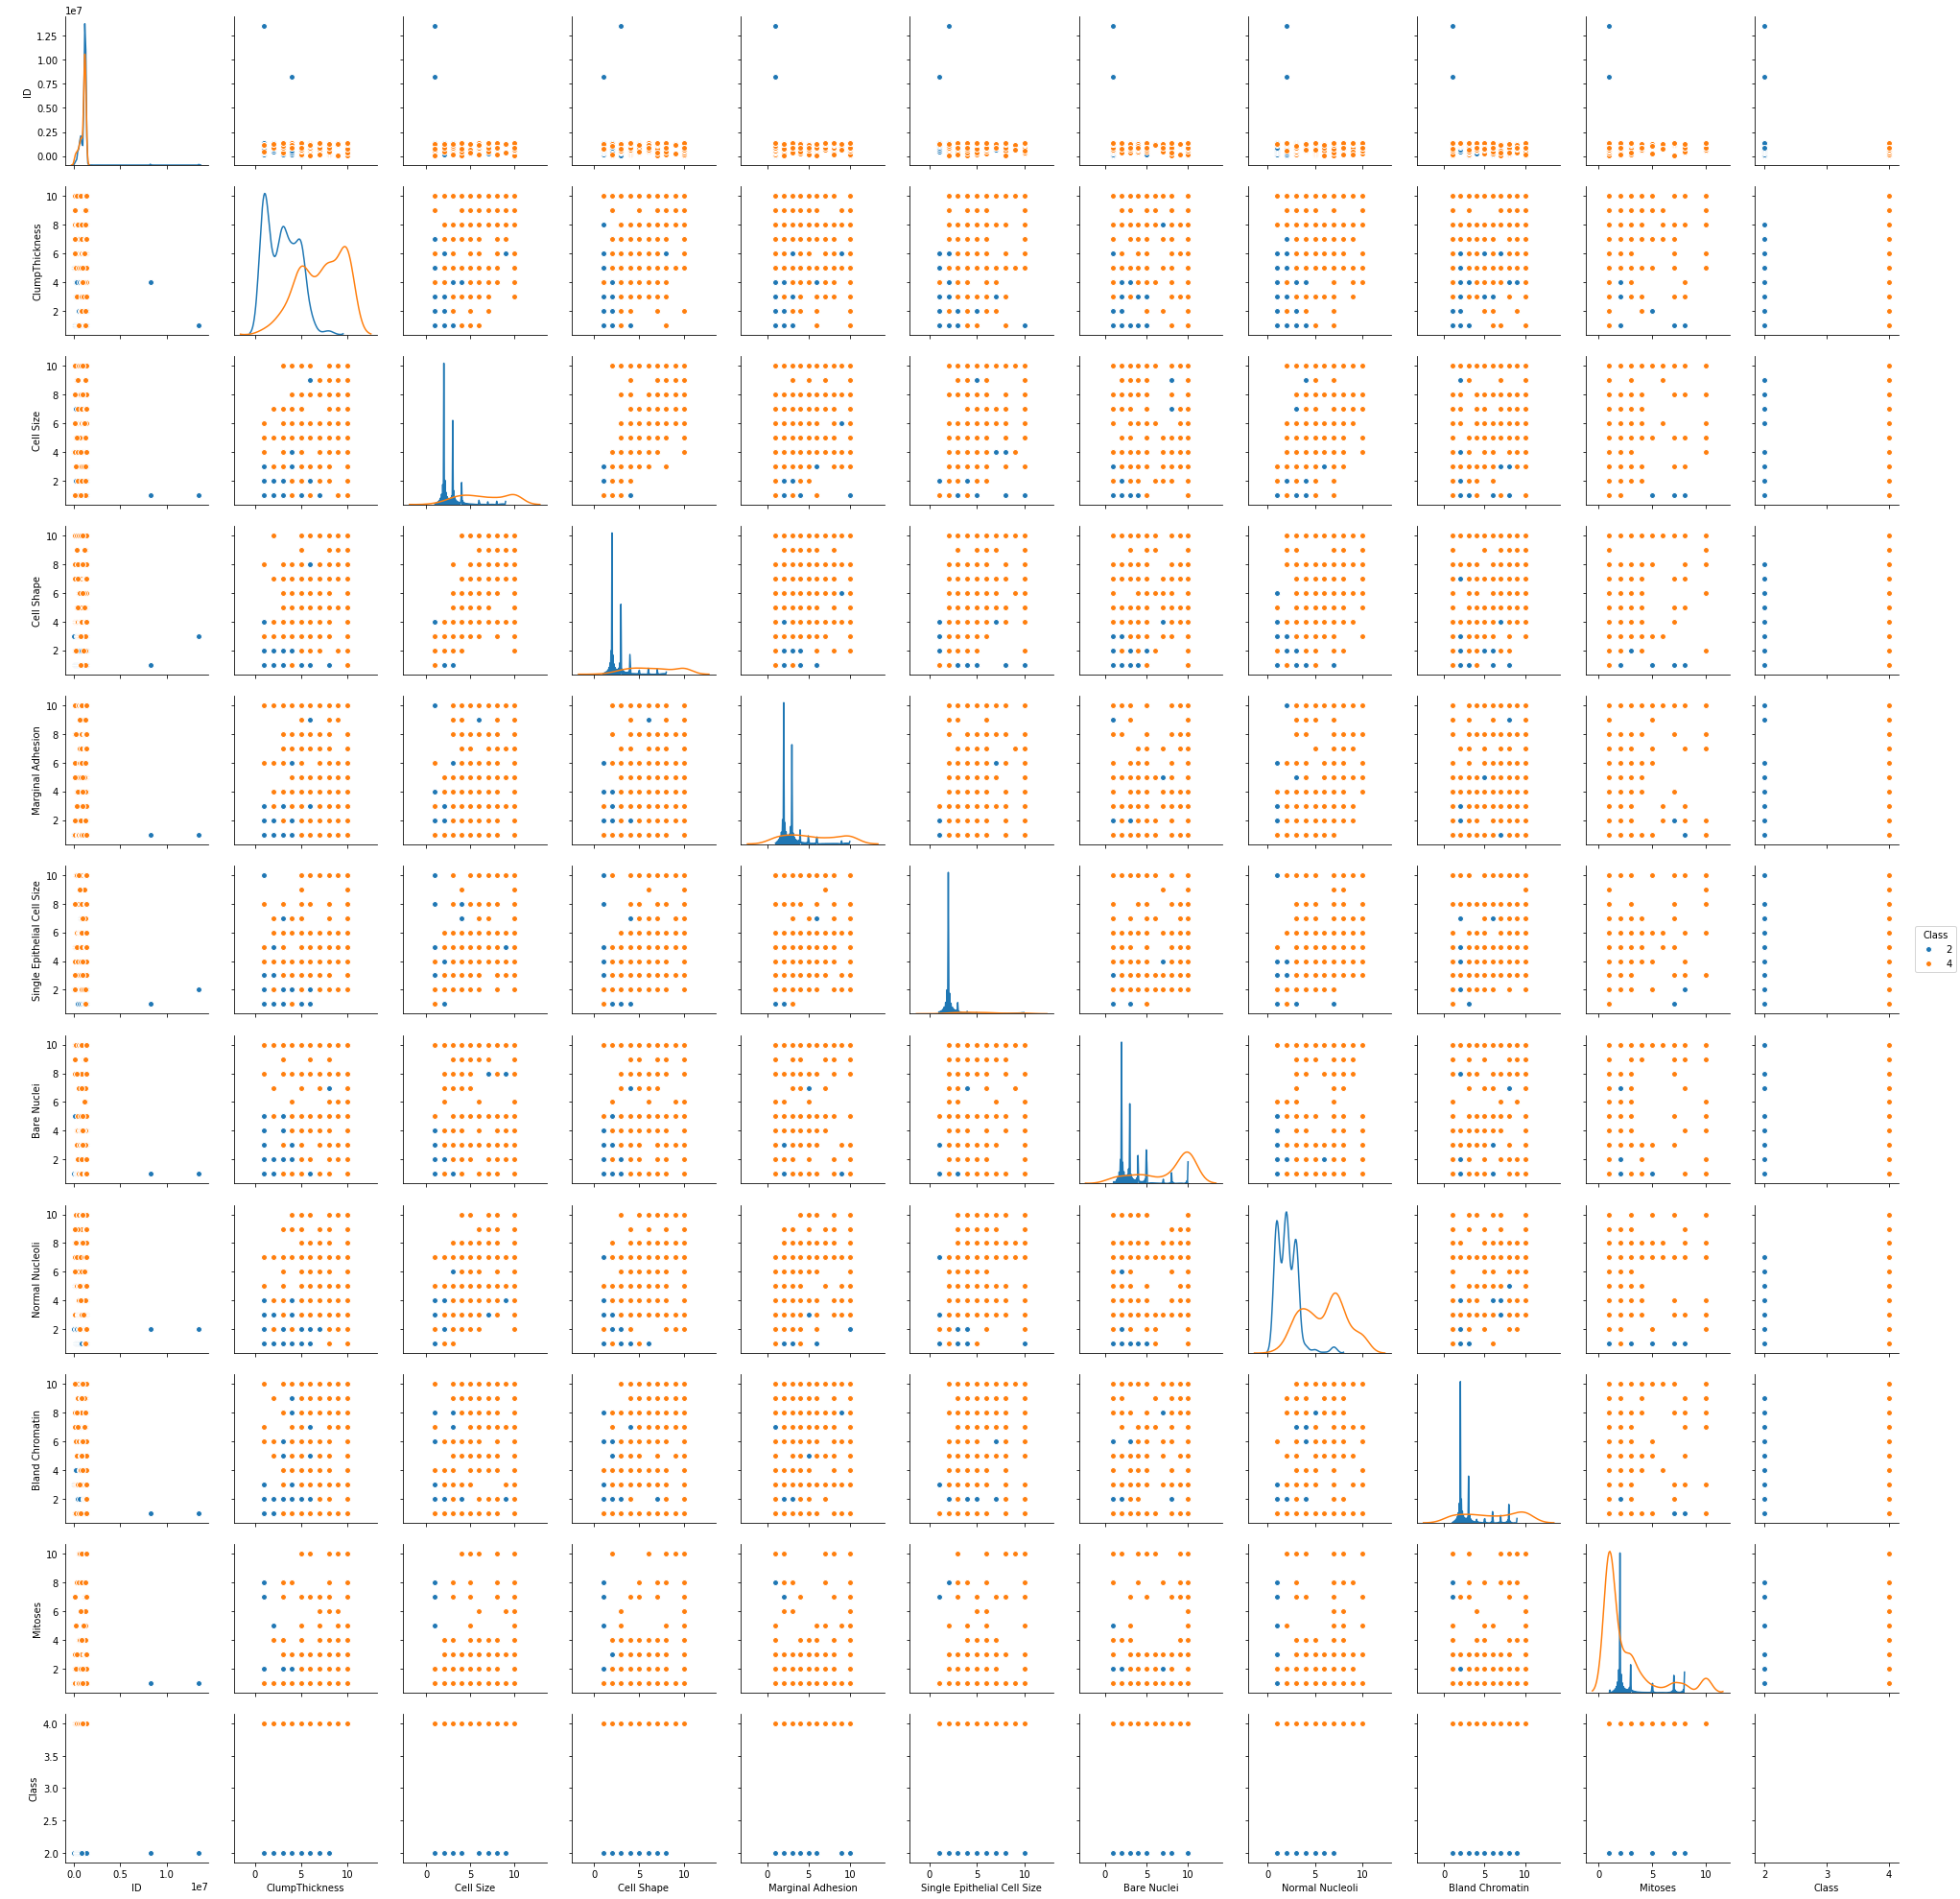

In [21]:
#Let us check for pair plots
can_df["Bare Nuclei"] = pd.to_numeric(can_df["Bare Nuclei"])
sns.pairplot(can_df, diag_kind='kde',hue='Class')

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

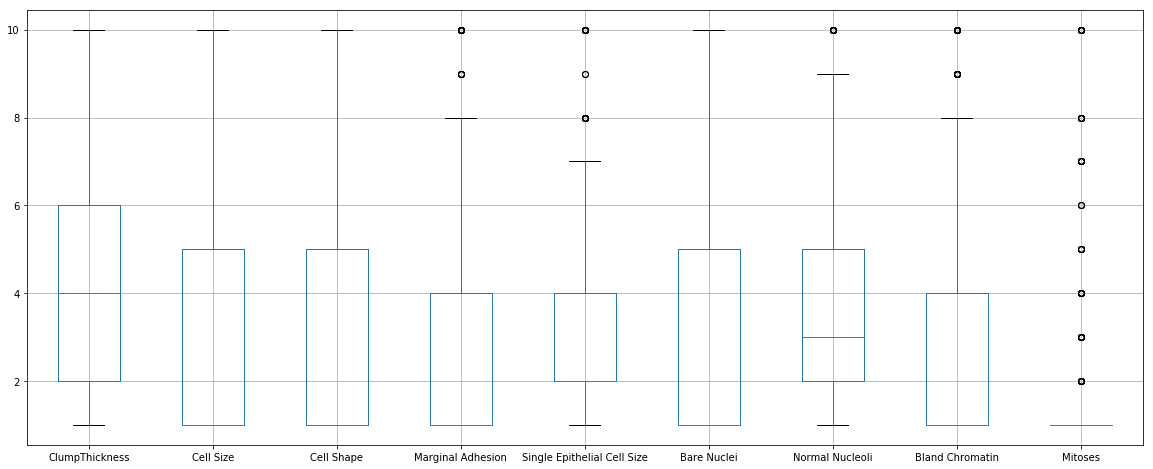

In [22]:
#plot Box Plots to check outlier
can_df.boxplot(column=['ClumpThickness','Cell Size','Cell Shape','Marginal Adhesion','Single Epithelial Cell Size',
                      'Bare Nuclei','Normal Nucleoli','Bland Chromatin','Mitoses'],figsize=(20,8))

In [23]:
#There are outliers in few of the columns. Lets do cross tab to find the count of target variable with respect to these columns
#And replace them with suitable values

In [24]:
pd.crosstab(can_df['Marginal Adhesion'], can_df['Class'])

Class,2,4
Marginal Adhesion,,
1,375,32
2,37,21
3,31,27
4,5,28
5,4,19
6,4,18
7,0,13
8,0,25
9,1,4


In [25]:
can_df['Marginal Adhesion']=np.where(can_df['Marginal Adhesion']>4,4,can_df['Marginal Adhesion'])

In [26]:
pd.crosstab(can_df['Marginal Adhesion'], can_df['Class'])

Class,2,4
Marginal Adhesion,,
1,375,32
2,37,21
3,31,27
4,15,161


In [27]:
pd.crosstab(can_df['Single Epithelial Cell Size'], can_df['Class'])

Class,2,4
Single Epithelial Cell Size,,
1,46,1
2,363,23
3,29,43
4,7,41
5,5,34
6,2,39
7,3,9
8,2,19
9,0,2


In [28]:
can_df['Single Epithelial Cell Size']=np.where(can_df['Single Epithelial Cell Size']>4,4,can_df['Single Epithelial Cell Size'])

In [29]:
pd.crosstab(can_df['Single Epithelial Cell Size'], can_df['Class'])

Class,2,4
Single Epithelial Cell Size,,
1,46,1
2,363,23
3,29,43
4,20,174


In [30]:
pd.crosstab(can_df['Normal Nucleoli'], can_df['Class'])

Class,2,4
Normal Nucleoli,,
1,150,2
2,159,7
3,129,36
4,8,32
5,4,30
6,1,9
7,7,66
8,0,28
9,0,11


In [31]:
can_df['Normal Nucleoli']=np.where(can_df['Normal Nucleoli']>4,4,can_df['Normal Nucleoli'])

In [32]:
pd.crosstab(can_df['Normal Nucleoli'], can_df['Class'])

Class,2,4
Normal Nucleoli,,
1,150,2
2,159,7
3,129,36
4,20,196


In [33]:
pd.crosstab(can_df['Bland Chromatin'], can_df['Class'])

Class,2,4
Bland Chromatin,,
1,402,41
2,30,6
3,12,32
4,1,17
5,2,17
6,4,18
7,2,14
8,4,20
9,1,15


In [34]:
can_df['Bland Chromatin']=np.where(can_df['Bland Chromatin']>4,4,can_df['Bland Chromatin'])

In [35]:
pd.crosstab(can_df['Bland Chromatin'], can_df['Class'])

Class,2,4
Bland Chromatin,,
1,402,41
2,30,6
3,12,32
4,14,162


In [36]:
pd.crosstab(can_df['Mitoses'], can_df['Class'])

Class,2,4
Mitoses,,
1,445,134
2,8,27
3,2,31
4,0,12
5,1,5
6,0,3
7,1,8
8,1,7
10,0,14


In [37]:
can_df['Mitoses']=np.where(can_df['Mitoses']>1,1,can_df['Mitoses'])

In [38]:
pd.crosstab(can_df['Mitoses'], can_df['Class'])

Class,2,4
Mitoses,,
1,458,241


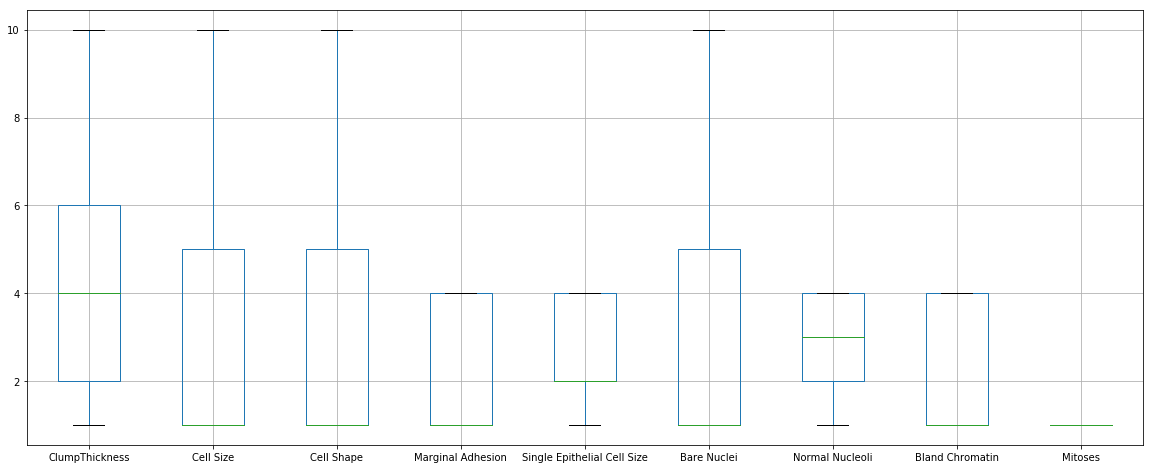

In [39]:
#check if outliers are still there or not
can_df.boxplot(column=['ClumpThickness','Cell Size','Cell Shape','Marginal Adhesion','Single Epithelial Cell Size',
                      'Bare Nuclei','Normal Nucleoli','Bland Chromatin','Mitoses'],figsize=(20,8))

In [40]:
can_df.shape

(699, 11)

In [41]:
#Deleting rows which are entirely same. Keeping the first record in case of duplicates are found
can_df = can_df.drop_duplicates()

In [42]:
can_df.shape

(690, 11)

# Q6 Create a covariance matrix for identifying Principal components

In [43]:
# PCA
# Step 1 - Create covariance matrix
# Dropping ID column as well here
X = can_df.drop(["Class","ID"],axis=1)
y = can_df["Class"]

In [44]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_std =  sc.fit_transform(X)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00145138 0.64410677 0.65453792 0.55329897 0.58388619 0.59150555
  0.54669109 0.57214901 0.        ]
 [0.64410677 1.00145138 0.9066632  0.72204998 0.77320789 0.68556472
  0.66940328 0.72684553 0.        ]
 [0.65453792 0.9066632  1.00145138 0.7042574  0.75066888 0.70518656
  0.65890363 0.71910723 0.        ]
 [0.55329897 0.72204998 0.7042574  1.00145138 0.6955125  0.69693138
  0.60427482 0.65326018 0.        ]
 [0.58388619 0.77320789 0.75066888 0.6955125  1.00145138 0.68280195
  0.6357667  0.72360753 0.        ]
 [0.59150555 0.68556472 0.70518656 0.69693138 0.68280195 1.00145138
  0.64237847 0.64168219 0.        ]
 [0.54669109 0.66940328 0.65890363 0.60427482 0.6357667  0.64237847
  1.00145138 0.65441737 0.        ]
 [0.57214901 0.72684553 0.71910723 0.65326018 0.72360753 0.64168219
  0.65441737 1.00145138 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]]


# Q7 Identify eigen values and eigen vector

In [45]:
# Step 2- Get eigen values and eigen vector

In [46]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[ 0.31573571  0.01382757  0.9080676  -0.08682989  0.1400738  -0.18213817
   0.1035049  -0.06697259  0.        ]
 [ 0.38130462  0.72099532  0.00521608  0.11888889 -0.019513    0.40597686
  -0.29680162  0.25946402  0.        ]
 [ 0.37944261 -0.68310043  0.05521985  0.23273886 -0.12294104  0.43276414
  -0.28454998  0.22093554  0.        ]
 [ 0.34869532 -0.04774969 -0.24824017  0.0240558   0.69770448 -0.05740145
  -0.23872651 -0.51657803  0.        ]
 [ 0.36294875 -0.06726377 -0.18250435 -0.81380045 -0.21536286 -0.2369166
  -0.21675824  0.13663823  0.        ]
 [ 0.34916145  0.07701137 -0.07780444  0.19275716 -0.6277279  -0.02856129
   0.1535959  -0.64070033  0.        ]
 [ 0.33372065 -0.02403065 -0.18403584 -0.13844155  0.19407039  0.28903591
   0.83039921  0.15572371  0.        ]
 [ 0.35261544  0.00597312 -0.19360542  0.45275532 -0.00239456 -0.68625197
   0.05565792  0.39888711  0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.        

# Q8 Find variance and cumulative variance by each eigen vector

In [47]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(5.719117364937859, array([0.31573571, 0.38130462, 0.37944261, 0.34869532, 0.36294875,
       0.34916145, 0.33372065, 0.35261544, 0.        ])), (0.4928843209768038, array([ 0.9080676 ,  0.00521608,  0.05521985, -0.24824017, -0.18250435,
       -0.07780444, -0.18403584, -0.19360542,  0.        ])), (0.42755913430066317, array([ 0.1035049 , -0.29680162, -0.28454998, -0.23872651, -0.21675824,
        0.1535959 ,  0.83039921,  0.05565792,  0.        ])), (0.40314479678263926, array([-0.06697259,  0.25946402,  0.22093554, -0.51657803,  0.13663823,
       -0.64070033,  0.15572371,  0.39888711,  0.        ])), (0.32536406306115767, array([-0.18213817,  0.40597686,  0.43276414, -0.05740145, -0.2369166 ,
       -0.02856129,  0.28903591, -0.68625197,  0.        ])), (0.2923659730145414, array([ 0.1400738 , -0.019513  , -0.12294104,  0.69770448, -0.21536286,
       -0.6277279 ,  0.19407039, -0.00239456,  0.        ])), (0.2593977389200882, array([-0.08682989,  0.11888889,  0.23273886,  0.024055

In [48]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  
cum_var_exp = np.cumsum(var_explained) 

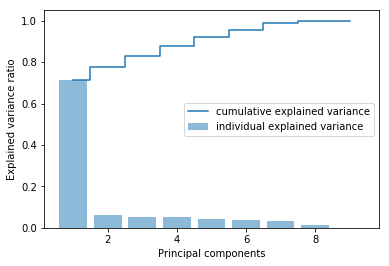

In [49]:
plt.bar(range(1,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [50]:
#From the above graph it looks like 7 can be good value for n_components
from sklearn.decomposition import PCA
X_centered = X - X.mean(axis=0)
pca = PCA(n_components=7)
pca.fit(X_centered)
X_pca = pca.transform(X_centered)
X_pca.shape

(690, 7)

# Q10 Find correlation between components and features

In [51]:
pca.components_

array([[ 0.37863755,  0.48116645,  0.47116521,  0.17685085,  0.13516784,
         0.54905779,  0.14504687,  0.17625602, -0.        ],
       [ 0.30645298,  0.37180943,  0.31645764, -0.02817828,  0.02077576,
        -0.81535713, -0.00844988,  0.03993222, -0.        ],
       [ 0.87154971, -0.3630498 , -0.31309954, -0.05888069, -0.05000302,
         0.03891337, -0.01942918, -0.0520158 ,  0.        ],
       [-0.02633568,  0.29367208, -0.62772887,  0.37170371,  0.20446572,
        -0.1079472 ,  0.33370417,  0.46479959, -0.        ],
       [ 0.0464335 ,  0.62273589, -0.42261527, -0.16358339, -0.10971191,
         0.1177176 , -0.31730812, -0.52735392, -0.        ],
       [ 0.01286372, -0.12635577,  0.07399765,  0.86775544,  0.03327109,
        -0.06208556, -0.38856266, -0.26353571,  0.        ],
       [ 0.0089374 ,  0.03238986, -0.04122982, -0.16667913,  0.10980085,
         0.04737902, -0.78411388,  0.58331262,  0.        ]])

In [52]:
pca.explained_variance_

array([33.61573401,  4.38979232,  3.5591166 ,  0.94186699,  0.78520305,
        0.59610167,  0.50267152])

In [53]:
pca.explained_variance_ratio_

array([0.75264469, 0.09828594, 0.07968739, 0.02108808, 0.01758043,
       0.01334651, 0.01125464])

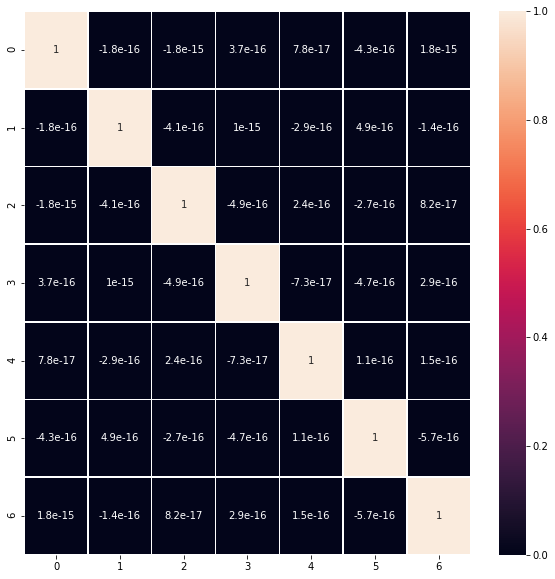

In [54]:
can_df_new=pd.DataFrame(X_pca)
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(can_df_new.corr(), annot=True,linewidths=.5, ax=ax)

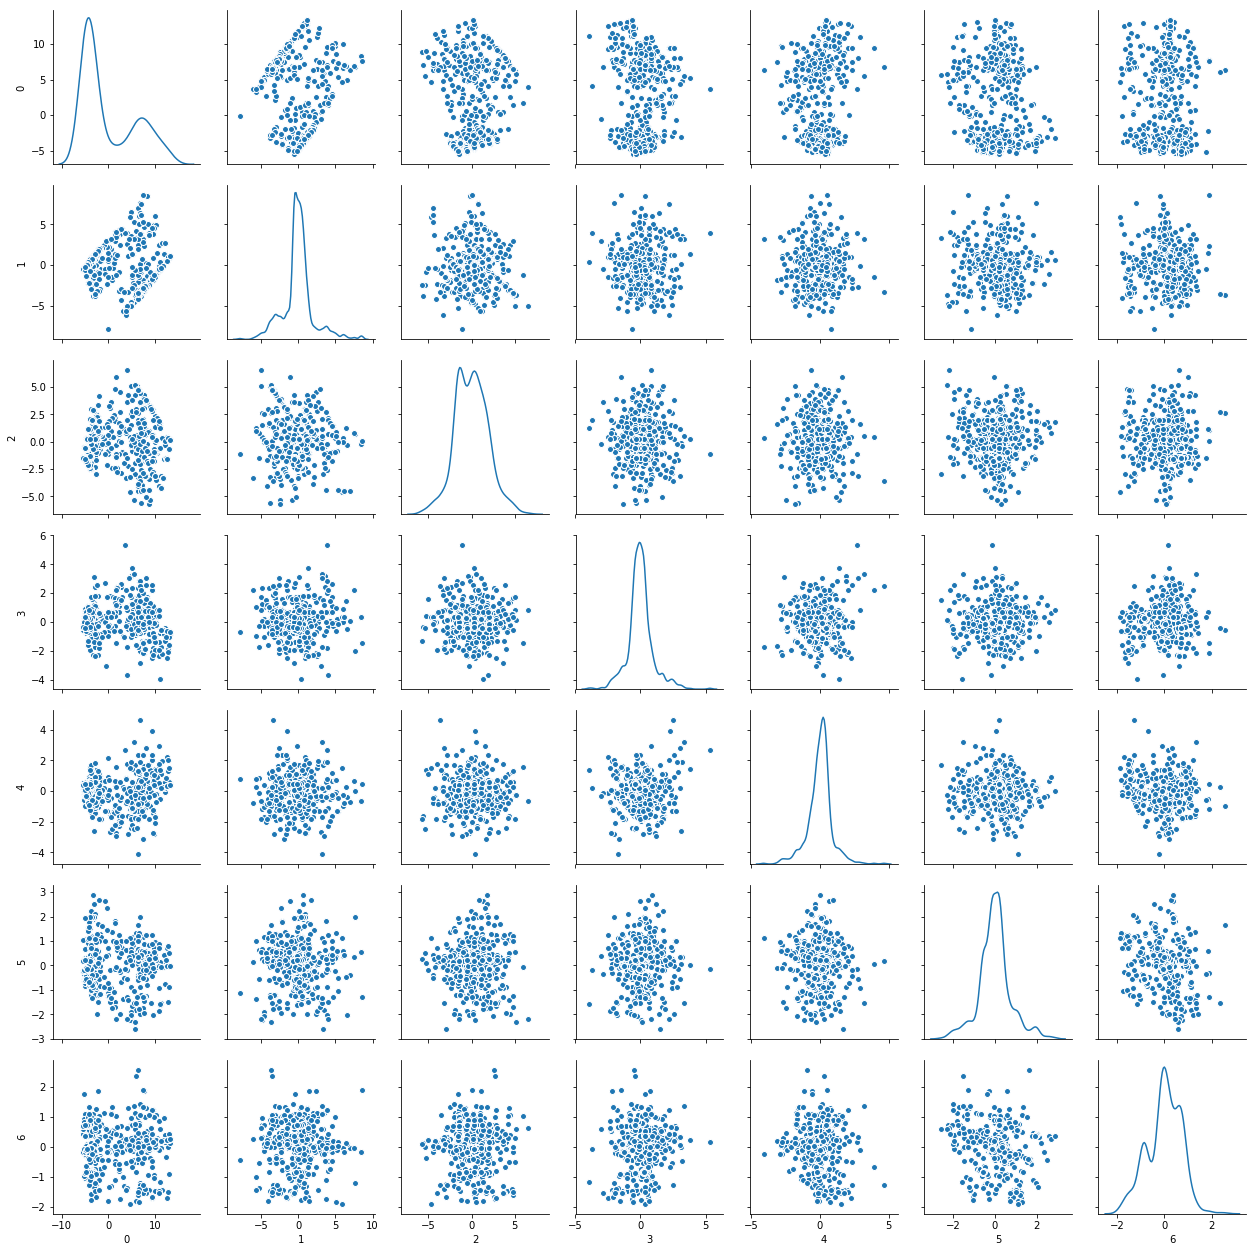

In [55]:
sns.pairplot(can_df_new, diag_kind='kde')

In [56]:
# From the heatmap we can observe that after doing PCA, the correlation among pca components were reduced. 
# From the pair plot also we can see that there is almost no correlation exist among components.